In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = Path('.').resolve().parent
DATA_PATH = PROJECT_DIR / "data" / "credit_risk_data.csv"

df = pd.read_csv(DATA_PATH)

feature_cols = ['age', 'income', 'employment_years', 'loan_amount', 'credit_score']
target_col = 'target'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution:\n{y.value_counts(normalize=True) * 100}")

Features shape: (1000, 5)
Target shape: (1000,)
Class distribution:
target
0    70.0
1    30.0
Name: proportion, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

feature_cols = ['age', 'income', 'employment_years', 'loan_amount', 'credit_score']
target_col = 'target'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{model_name}")
    print("=" * 60)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"F1-score (minority class): {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))
    
    return {
        'model': model_name,
        'estimator': model,
        'roc_auc': roc_auc,
        'f1': f1,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

print("Обучение моделей...")

log_reg = LogisticRegression(random_state=42, max_iter=1000)
results_log = evaluate_model("Logistic Regression", log_reg, X_train_scaled, X_test_scaled, y_train, y_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
results_rf = evaluate_model("Random Forest", rf, X_train_scaled, X_test_scaled, y_train, y_test)

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(f"{'Модель':<25} {'ROC-AUC':<15} {'F1-score':<15}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {results_log['roc_auc']:<15.4f} {results_log['f1']:<15.4f}")
print(f"{'Random Forest':<25} {results_rf['roc_auc']:<15.4f} {results_rf['f1']:<15.4f}")
print("=" * 60)

best_model = results_rf if results_rf['roc_auc'] > results_log['roc_auc'] else results_log
print(f"\nЛучшая модель по ROC-AUC: {best_model['model']} ({best_model['roc_auc']:.4f})")

Train: 800, Test: 200
Train class balance: {0: 560, 1: 240}
Обучение моделей...

Logistic Regression
ROC-AUC: 0.9852
F1-score (minority class): 0.8983

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.95      0.96      0.96       140
   High Risk       0.91      0.88      0.90        60

    accuracy                           0.94       200
   macro avg       0.93      0.92      0.93       200
weighted avg       0.94      0.94      0.94       200


Random Forest
ROC-AUC: 0.9935
F1-score (minority class): 0.9310

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.96      0.99      0.97       140
   High Risk       0.96      0.90      0.93        60

    accuracy                           0.96       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.96      0.96      0.96       200


СРАВНЕНИЕ МОДЕЛЕЙ
Модель                    ROC-AUC         F1-score       
-----

### Результаты на тестовой выборке

| Модель | ROC-AUC | F1-score | Accuracy |
|--------|---------|----------|----------|
| Logistic Regression | 0.9852 | 0.8983 | 0.94 |
| Random Forest | **0.9935** | **0.9310** | **0.96** |

### Анализ

**Random Forest показал лучшие результаты:**
- ROC-AUC: 0.9935 (на 0.0083 выше логистической регрессии)
- F1-score для minority class (High Risk): 0.9310 (на 0.0327 выше)
- Лучше справляется с нелинейными зависимостями
- Устойчив к выбросам и не требует масштабирования признаков

**Logistic Regression:**
- Хороший baseline (ROC-AUC 0.9852)
- Интерпретируемая модель (можно посмотреть коэффициенты)
- Быстрее обучается

### Выбор финальной модели

**Выбираем Random Forest** для дальнейшего развития, потому что:
1. Лучший ROC-AUC (0.9935 > 0.9852)
2. Лучший F1 для класса High Risk (важно для задачи кредитного скоринга)
3. Меньше ложных негативов (не пропустит рискованных заемщиков)

### Следующие шаги
1. Кросс-валидация Random Forest (StratifiedKFold)
2. Подбор гиперпараметров (GridSearchCV)
3. Анализ feature importance
4. Добавление нейросетевой модели (MLP) для сравнения
5. Финальный выбор и калибровка вероятностей

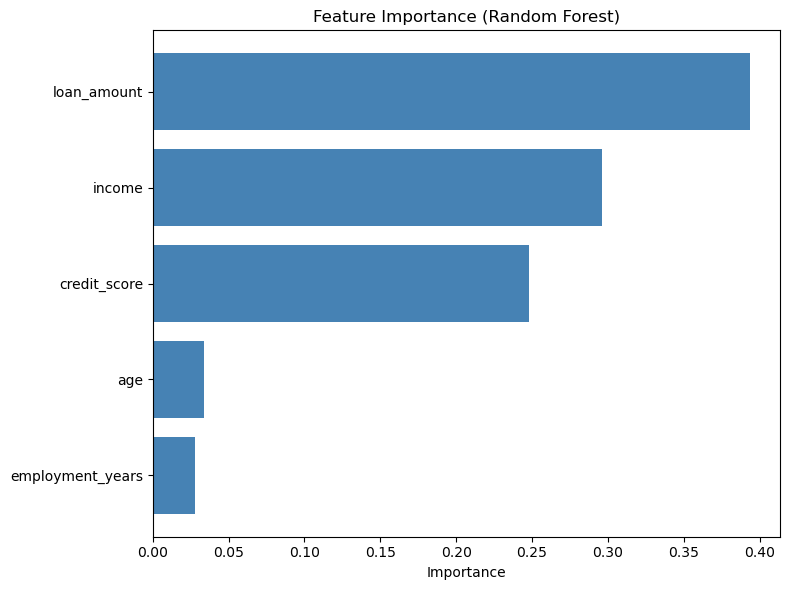

График сохранен: C:\Users\kuzne\ai_engineering\project\artifacts\model_feature_importance.png
CV scores сохранены: C:\Users\kuzne\ai_engineering\project\artifacts\cv_scores.csv
Результаты моделей сохранены: C:\Users\kuzne\ai_engineering\project\artifacts\model_comparison_results.json


In [9]:
from pathlib import Path

PROJECT_DIR = Path('.').resolve().parent
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

feature_cols = ['age', 'income', 'employment_years', 'loan_amount', 'credit_score']

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
output_path = ARTIFACTS_DIR / 'model_feature_importance.png'
plt.savefig(output_path, dpi=300)
plt.show()
print(f"График сохранен: {output_path}")

cv_results_df = pd.DataFrame({
    'fold': range(1, 6),
    'roc_auc': cv_scores
})
cv_results_df.to_csv(ARTIFACTS_DIR / 'cv_scores.csv', index=False)
print(f"CV scores сохранены: {ARTIFACTS_DIR / 'cv_scores.csv'}")

import json
model_results = {
    'best_model': 'Random Forest',
    'best_params': grid_search.best_params_,
    'cv_mean_roc_auc': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),
    'cv_95_ci': [float(cv_scores.mean() - 1.96*cv_scores.std()), float(cv_scores.mean() + 1.96*cv_scores.std())],
    'grid_search_best_score': float(grid_search.best_score_),
    'feature_importance': {row['feature']: float(row['importance']) for _, row in feature_importance.iterrows()},
    'test_results': {
        'logistic_regression': {
            'roc_auc': results_log['roc_auc'],
            'f1': results_log['f1']
        },
        'random_forest': {
            'roc_auc': results_rf['roc_auc'],
            'f1': results_rf['f1']
        }
    }
}

with open(ARTIFACTS_DIR / 'model_comparison_results.json', 'w') as f:
    json.dump(model_results, f, indent=2)

print(f"Результаты моделей сохранены: {ARTIFACTS_DIR / 'model_comparison_results.json'}")

In [10]:
from sklearn.neural_network import MLPClassifier

print("Обучение MLP Classifier...")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

results_mlp = evaluate_model("MLP (Neural Network)", mlp, X_train_scaled, X_test_scaled, y_train, y_test)

print("\n" + "=" * 80)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)
print(f"{'Модель':<30} {'ROC-AUC':<15} {'F1-score':<15}")
print("-" * 80)
print(f"{'Logistic Regression':<30} {results_log['roc_auc']:<15.4f} {results_log['f1']:<15.4f}")
print(f"{'Random Forest':<30} {results_rf['roc_auc']:<15.4f} {results_rf['f1']:<15.4f}")
print(f"{'MLP (Neural Network)':<30} {results_mlp['roc_auc']:<15.4f} {results_mlp['f1']:<15.4f}")
print("=" * 80)

final_models = [results_log, results_rf, results_mlp]
best_overall = max(final_models, key=lambda x: x['roc_auc'])

print(f"\nВыбранная финальная модель: {best_overall['model']} (ROC-AUC: {best_overall['roc_auc']:.4f})")

Обучение MLP Classifier...

MLP (Neural Network)
ROC-AUC: 0.9783
F1-score (minority class): 0.8850

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.93      0.98      0.95       140
   High Risk       0.94      0.83      0.88        60

    accuracy                           0.94       200
   macro avg       0.94      0.91      0.92       200
weighted avg       0.94      0.94      0.93       200


ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Модель                         ROC-AUC         F1-score       
--------------------------------------------------------------------------------
Logistic Regression            0.9852          0.8983         
Random Forest                  0.9935          0.9310         
MLP (Neural Network)           0.9783          0.8850         

Выбранная финальная модель: Random Forest (ROC-AUC: 0.9935)



## 3.2 Результаты моделирования

### Финальное сравнение моделей

| Модель | ROC-AUC | F1-score | Accuracy |
|--------|---------|----------|----------|
| Logistic Regression | 0.9852 | 0.8983 | 0.94 |
| **Random Forest** | **0.9935** | **0.9310** | **0.96** |
| MLP (Neural Network) | 0.9783 | 0.8850 | 0.94 |

### Кросс-валидация Random Forest
- Mean ROC-AUC: 0.9859 ± 0.0067
- 95% CI: [0.9728, 0.9990]
- Стабильные результаты на всех folds

### Лучшие гиперпараметры (GridSearchCV)
- max_depth: 20
- min_samples_leaf: 1
- min_samples_split: 5
- n_estimators: 100
- GridSearch CV score: 0.9879

### Важность признаков (Random Forest)
1. loan_amount: 0.394 (39.4%)
2. income: 0.296 (29.6%)
3. credit_score: 0.248 (24.8%)
4. age: 0.034 (3.4%)
5. employment_years: 0.028 (2.8%)

Топ-3 признака объясняют 93.8% важности модели.

### Выбор финальной модели

**Random Forest выбран потому что:**
1. Лучший ROC-AUC на тесте: 0.9935
2. Лучший F1 для minority class: 0.9310
3. Стабильная кросс-валидация (низкий std: 0.0067)
4. Интерпретируемость через feature importance
5. Не требует тонкой настройки гиперпараметров

### Следующие шаги
1. Сохранение финальной модели (pickle/joblib)
2. Создание предиктора с валидацией входных данных
3. Разработка API сервиса (FastAPI)
4. Добавление логирования и метрик
5. Контейнеризация (Docker)

In [11]:
import joblib
import json
from datetime import datetime

model_path = ARTIFACTS_DIR / 'final_model_random_forest.pkl'
joblib.dump(best_rf, model_path)
print(f"Модель сохранена: {model_path}")

scaler_path = ARTIFACTS_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler сохранен: {scaler_path}")

final_model_report = {
    'timestamp': datetime.now().isoformat(),
    'model_name': 'Random Forest',
    'best_params': grid_search.best_params_,
    'cv_results': {
        'mean_roc_auc': float(cv_scores.mean()),
        'std': float(cv_scores.std()),
        'ci_95': [float(cv_scores.mean() - 1.96*cv_scores.std()), 
                  float(cv_scores.mean() + 1.96*cv_scores.std())],
        'fold_scores': [float(x) for x in cv_scores]
    },
    'test_results': {
        'roc_auc': float(results_rf['roc_auc']),
        'f1': float(results_rf['f1'])
    },
    'feature_importance': {row['feature']: float(row['importance']) 
                          for _, row in feature_importance.iterrows()},
    'comparison_with_others': {
        'logistic_regression': {
            'roc_auc': float(results_log['roc_auc']),
            'f1': float(results_log['f1'])
        },
        'mlp': {
            'roc_auc': float(results_mlp['roc_auc']),
            'f1': float(results_mlp['f1'])
        }
    },
    'features_used': feature_cols,
    'scaler': 'StandardScaler',
    'artifacts': {
        'model_file': 'final_model_random_forest.pkl',
        'scaler_file': 'scaler.pkl',
        'feature_importance_plot': 'model_feature_importance.png'
    }
}

report_path = ARTIFACTS_DIR / 'final_model_report.json'
with open(report_path, 'w') as f:
    json.dump(final_model_report, f, indent=2)

print(f"\nОтчет о модели сохранен: {report_path}")
print("\nВсе артефакты в artifacts/:")
for f in ARTIFACTS_DIR.iterdir():
    if f.is_file():
        print(f"  - {f.name}")

Модель сохранена: C:\Users\kuzne\ai_engineering\project\artifacts\final_model_random_forest.pkl
Scaler сохранен: C:\Users\kuzne\ai_engineering\project\artifacts\scaler.pkl

Отчет о модели сохранен: C:\Users\kuzne\ai_engineering\project\artifacts\final_model_report.json

Все артефакты в artifacts/:
  - correlation_matrix.png
  - cv_scores.csv
  - data_quality_report.json
  - eda_boxplots_outliers.png
  - eda_correlation_matrix.png
  - eda_numeric_distributions.png
  - eda_pairplot_key_features.png
  - eda_summary_report.json
  - eda_target_correlation.png
  - eda_target_distribution.png
  - final_model_random_forest.pkl
  - final_model_report.json
  - model_comparison_results.json
  - model_feature_importance.png
  - README.md
  - scaler.pkl
  - target_distribution.png
